# Phân tích chuyên sâu về chỉ số Di truyền Tiểu đường (Diabetes Pedigree Function)

Notebook này được tạo để phân tích riêng về biến `DiabetesPedigreeFunction` trong tập dữ liệu Pima Indians Diabetes. Chỉ số này đánh giá mức độ ảnh hưởng của yếu tố gia đình đối với khả năng mắc bệnh.

**Trọng tâm:**
* Thống kê mô tả chi tiết về biến Pedigree.
* Kiểm tra giá trị thiếu (Missing Values).
* Phân tích hình dạng phân phối của dữ liệu (Distribution).

In [20]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid")

repo_root = Path().resolve().parent.parent
data_path = repo_root / "Lab_03" / "data" / "pima-indians-diabetes.csv"

column_names = [
    "pregnancies", "glucose", "blood_pressure", "skin_thickness", 
    "insulin", "bmi", "diabetes_pedigree_function", "age", "outcome"
]

df = pd.read_csv(data_path, header=None, names=column_names)

# Hiển thị để kiểm tra
df[['diabetes_pedigree_function', 'outcome']].head()

,diabetes_pedigree_function,outcome
0,0.627,1
1,0.351,0
2,0.672,1
3,0.167,0
4,2.288,1


## 1. Dữ liệu gốc (Bao gồm các giá trị phân phối)
Trong dữ liệu gốc, chúng ta sẽ xem xét hình dáng phân phối của biến `diabetes_pedigree_function` để xác định độ lệch (skewness) và các giá trị tiềm năng.

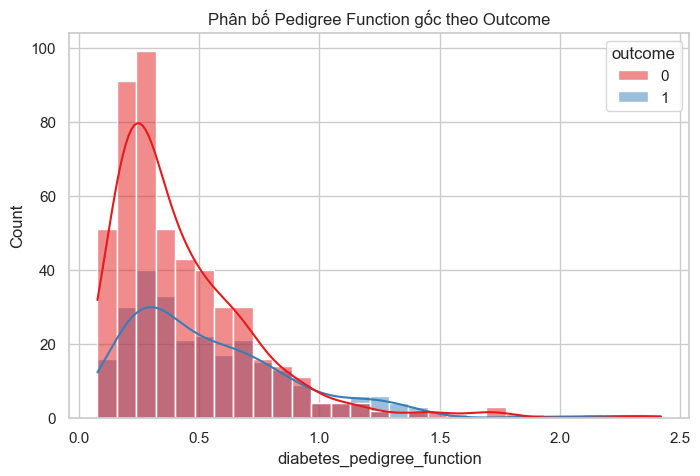

In [21]:
# Biểu đồ phân bố dữ liệu gốc
fig_raw, ax_raw = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df,
    x="diabetes_pedigree_function",
    hue="outcome",
    kde=True,
    ax=ax_raw,
    palette="Set1"
)
ax_raw.set_title("Phân bố Pedigree Function gốc theo Outcome")
plt.show()

## 2. Thống kê mô tả và kiểm tra giá trị thiếu

In [22]:
print("Chỉ số thống kê chi tiết:")
display(df[['diabetes_pedigree_function']].describe().T)

Chỉ số thống kê chi tiết:


,count,mean,std,min,25%,50%,75%,max
diabetes_pedigree_function,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42


In [23]:
# Kiểm tra giá trị bằng 0
zero_pedigree = (df['diabetes_pedigree_function'] == 0).sum()
print(f"\nSố lượng mẫu có Pedigree bằng 0: {zero_pedigree}")


Số lượng mẫu có Pedigree bằng 0: 0


> **Nhận xét sơ bộ:**
> * Biến `diabetes_pedigree_function` có sự phân bố **lệch phải (Skewed Right)** rất rõ rệt. Đa số dữ liệu tập trung ở khoảng 0.1 đến 0.8.
> * Không có giá trị bằng 0, cho thấy biến này không bị lỗi dữ liệu thiếu (missing values) như BMI hay Insulin.
> * Nhóm có bệnh (Outcome 1 - màu đỏ) có xu hướng trải dài hơn về phía các giá trị cao hơn so với nhóm không bệnh.

## 3. Xác định giá trị ngoại lai (Outliers) bằng Boxplot
Sử dụng biểu đồ Boxplot để quan sát các giá trị bất thường và so sánh trực quan phạm vi biến thiên của chỉ số Pedigree giữa hai nhóm Outcome.

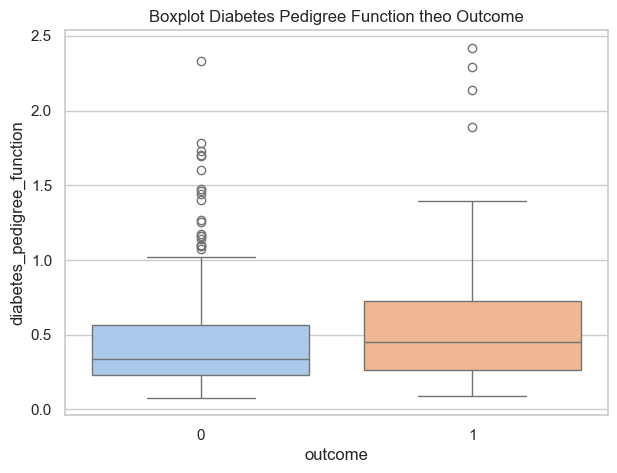

In [24]:
fig_box, ax_box = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="outcome",
    y="diabetes_pedigree_function",
    hue="outcome",
    ax=ax_box,
    palette="pastel",
    legend=False
)
ax_box.set_title("Boxplot Diabetes Pedigree Function theo Outcome")
plt.show()

> **Kết luận:**
> 1. **Dữ liệu sạch:** Biến không có giá trị thiếu (null) hoặc giá trị bằng 0 vô lý.
> 2. **Phân phối:** Chỉ số Pedigree tập trung chủ yếu ở mức thấp (dưới 1.0). Tuy nhiên, biểu đồ Boxplot cho thấy rất nhiều **điểm ngoại lai (outliers)** ở cả hai nhóm, đặc biệt là nhóm mắc bệnh (Outcome 1).
> 3. **Xu hướng:** Nhóm Outcome 1 có trung vị (median) và các mức phân vị cao hơn so với nhóm Outcome 0, cho thấy sự liên quan tiềm tàng giữa di truyền và khả năng mắc bệnh.